# Predictive Maintenance using Machine Learning

## Problem Statement
Unexpected machine failures cause downtime and financial loss.  
This project predicts machine failures using sensor data to enable proactive maintenance.

In [1]:
import pandas as pd
pm=pd.read_csv("ai4i2020.csv")
pm.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset Overview

The dataset contains machine sensor readings such as:
- Air Temperature
- Process Temperature
- Rotational Speed
- Torque
- Tool Wear

Target:
- Machine Failure (0 = No Failure, 1 = Failure)

In [2]:
pm.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [3]:
pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
pm.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
pm.duplicated().sum()

np.int64(0)

In [6]:
pm.drop(columns=["UDI","Product ID"], inplace=True)

In [7]:
pm.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [8]:
pm['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

## Data Preprocessing

- Removed unnecessary columns
- Cleaned column names
- Encoded categorical variables
- Removed leakage features (TWF, HDF, PWF, OSF, RNF)

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [10]:
pm.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [11]:
pm.columns = pm.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [12]:
pm.columns

Index(['Type', 'Air_temperature_K_', 'Process_temperature_K_',
       'Rotational_speed_rpm_', 'Torque_Nm_', 'Tool_wear_min_',
       'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [13]:
pm['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [14]:
dummies = pd.get_dummies(pm['Type'])

pm = pd.concat([pm, dummies], axis=1)

pm.drop(columns=['Type'], inplace=True)

In [15]:
pm.columns

Index(['Air_temperature_K_', 'Process_temperature_K_', 'Rotational_speed_rpm_',
       'Torque_Nm_', 'Tool_wear_min_', 'Machine_failure', 'TWF', 'HDF', 'PWF',
       'OSF', 'RNF', 'H', 'L', 'M'],
      dtype='object')

In [16]:
x = pm.drop(columns=['Machine_failure','TWF', 'HDF', 'PWF',
       'OSF', 'RNF'])
y = pm['Machine_failure']

## Feature Engineering

New features were created to capture machine behavior:

- Temperature difference
- Load factor
- Wear-speed ratio
- Power estimation

In [17]:
pm['temp_diff'] = pm['Process_temperature_K_'] - pm['Air_temperature_K_']
pm['load_factor'] = pm['Torque_Nm_'] * pm['Rotational_speed_rpm_']
pm['wear_speed_ratio'] = pm['Tool_wear_min_'] / (pm['Rotational_speed_rpm_'] + 1)
pm['power'] = pm['Torque_Nm_'] * (pm['Rotational_speed_rpm_'] / 60)

In [18]:
pm.columns

Index(['Air_temperature_K_', 'Process_temperature_K_', 'Rotational_speed_rpm_',
       'Torque_Nm_', 'Tool_wear_min_', 'Machine_failure', 'TWF', 'HDF', 'PWF',
       'OSF', 'RNF', 'H', 'L', 'M', 'temp_diff', 'load_factor',
       'wear_speed_ratio', 'power'],
      dtype='object')

## Handling Imbalanced Data

SMOTE was applied to balance failure and non-failure cases.

In [19]:
from imblearn.over_sampling import SMOTE

X = pm.drop(columns=['Machine_failure','TWF','HDF','PWF','OSF','RNF'])
Y = pm['Machine_failure']


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, stratify=Y, random_state=42, test_size=0.2
)
sm = SMOTE(random_state=42)
X_train, Y_train = sm.fit_resample(X_train, Y_train)

In [20]:
Y_train.value_counts()

Machine_failure
0    7729
1    7729
Name: count, dtype: int64

## Model Selection

LightGBM was selected due to its efficiency and strong performance on tabular data.

### Manual Hyperparameter Tuning

An initial LightGBM model was developed using manually selected hyperparameters. 

This approach was used to understand the influence of key parameters such as learning rate, number of estimators, and tree complexity on model behavior. It provided a baseline and helped build intuition about how the model responds to different configurations.

Manual tuning served as the foundation for further optimization by identifying reasonable parameter ranges for more systematic search methods.

In [21]:
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

manual_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=2,
    random_state=42
)

manual_model.fit(X_train, Y_train)

y_pred_manual = manual_model.predict(X_test)
print("Manual Model:")
print("Precision:", round(precision_score(Y_test, y_pred_manual)*100,2), "%")
print("Recall:", round(recall_score(Y_test, y_pred_manual)*100,2), "%")
print("F1 Score:", round(f1_score(Y_test, y_pred_manual)*100,2), "%")

[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2292
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Manual Model:
Precision: 74.03 %
Recall: 83.82 %
F1 Score: 78.62 %


### Randomized Hyperparameter Optimization

To improve model performance, RandomizedSearchCV was applied to explore a broader range of hyperparameter combinations.

Unlike manual tuning, this method samples different parameter combinations efficiently, allowing the model to identify better configurations without exhaustively searching the entire parameter space.

The optimization process focused on balancing model performance while avoiding overfitting, making it suitable for handling the complexity of the dataset.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 70],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

model = LGBMClassifier(random_state=42)

random_search = RandomizedSearchCV(
    model,
    param_dist,
    n_iter=25,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, Y_train)

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Random Search Model:")
print("Precision:", round(precision_score(Y_test, y_pred_best)*100,2), "%")
print("Recall:", round(recall_score(Y_test, y_pred_best)*100,2), "%")
print("F1 Score:", round(f1_score(Y_test, y_pred_best)*100,2), "%")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000524 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2292
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Random Search Model:
Precision: 83.58 %
Recall: 82.35 %
F1 Score: 82.96 %


### Probability Calibration

Probability calibration was applied to refine the predicted probabilities of the model.

Using CalibratedClassifierCV, the model’s probability outputs were adjusted to better represent the true likelihood of failure events. This step is particularly useful for improving decision-making in threshold-based systems.

Calibration focuses on improving probability reliability rather than directly optimizing classification performance.

In [23]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated_model.fit(X_train, Y_train)
y_pred_cali = calibrated_model.predict(X_test)
from sklearn.metrics import precision_score, recall_score, f1_score

print("Calibrated Model:")
print("Precision:", round(precision_score(Y_test, y_pred_cali)*100,2), "%")
print("Recall:", round(recall_score(Y_test, y_pred_cali)*100,2), "%")
print("F1 Score:", round(f1_score(Y_test, y_pred_cali)*100,2), "%")

[LightGBM] [Info] Number of positive: 5153, number of negative: 5152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2288
[LightGBM] [Info] Number of data points in the train set: 10305, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500049 -> initscore=0.000194
[LightGBM] [Info] Start training from score 0.000194
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## Model Comparison

Multiple models and optimization techniques were evaluated to identify the best-performing approach for failure prediction.

| Model | Precision | Recall | F1 Score |
|------|----------|--------|----------|
| XGBoost (Default) | 54.76% | 75.41% | 63.45% |
| XGBoost (Tuned) | 51.72% | 73.77% | 60.81% |
| LightGBM (500 Estimators) | 65.15% | 70.49% | 67.72% |
| LightGBM (Manual Tuning) | 75.00% | **83.82%** | 79.17% |
| LightGBM (Random Search) | **83.58%** | 82.35% | **82.96%** |
| LightGBM (Calibrated) | 75.00% | **83.82%** | 79.17% |

The manually tuned LightGBM model significantly improved recall but resulted in lower precision, indicating a higher number of false alarms.

RandomizedSearchCV further improved performance by identifying optimal hyperparameter combinations, achieving the highest F1-score (~82.96%) with a strong balance between precision and recall.

Calibration was applied to improve probability estimates; however, it did not lead to improvements in classification performance and therefore was not selected as the final model.

The LightGBM model optimized using Random Search was selected as the final model because it achieves the best overall balance between precision and recall, significantly reduces false positives, and maintains strong failure detection capability.

This makes it the most practical and reliable model for real-world predictive maintenance applications.

In [24]:
best_params = random_search.best_params_

In [25]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("model",LGBMClassifier(
    **best_params,
    n_jobs=2, 
    random_state=42
))
])

pipeline.fit(X_train, Y_train)


[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2292
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None


In [26]:
pipeline.classes_

array([0, 1])

In [27]:
y_pred = pipeline.predict(X_test)

CR1 = classification_report(Y_test, y_pred, output_dict=True)


y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob > 0.2).astype(int)


CR2 = classification_report(Y_test, y_pred_thresh, output_dict=True)


precision = CR1['1']['precision']
recall = CR1['1']['recall']
f1 = CR1['1']['f1-score']

print("\n--- Default Model Metrics ---")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")


precision_t = CR2['1']['precision']
recall_t = CR2['1']['recall']
f1_t = CR2['1']['f1-score']

print("\n--- Threshold Model Metrics(Threshold = 0.3 (Recall Focus)) ---")
print(f"Precision: {precision_t*100:.2f}%")
print(f"Recall: {recall_t*100:.2f}%")
print(f"F1 Score: {f1_t*100:.2f}%")


--- Default Model Metrics ---
Precision: 83.58%
Recall: 82.35%
F1 Score: 82.96%

--- Threshold Model Metrics(Threshold = 0.3 (Recall Focus)) ---
Precision: 74.03%
Recall: 83.82%
F1 Score: 78.62%


## Model Performance

- Precision: 83.58%
- Recall: 82.35%
- F1 Score: 82.96%

The model demonstrates strong and well-balanced performance, with high recall ensuring most failure cases are correctly identified, while maintaining good precision to limit false alarms.

---

### Analysis

- The **manual and threshold-based models** achieved slightly higher recall, reducing false negatives.
- However, these models resulted in **significantly lower precision**, leading to a higher number of false alarms.
- The **Random Search model** achieved the **highest F1-score (82.96%)**, indicating the best balance between precision and recall.
- Threshold tuning (0.3) increased recall marginally but caused a **large drop in precision**, making the system less reliable due to excessive false positives.
- Calibration improved probability estimates but did not enhance classification performance.

---

### Final Model Selection

Although minimizing false negatives is important in predictive maintenance, the threshold-based model did not provide a meaningful improvement in recall and introduced a substantial increase in false positives.

The Random Search optimized LightGBM model was selected as the final model because it:

- Achieves the highest overall F1-score  
- Maintains strong recall for failure detection  
- Significantly reduces false alarms compared to other approaches  

This balance ensures both **operational reliability and practical usability**, making it the most suitable model for deployment.

## Advanced Model Evaluation

To further evaluate the model’s robustness and real-world applicability, additional performance metrics and validation techniques were applied. These methods provide deeper insights into model stability, classification strength, and interpretability.

### Cross-Validation Performance

Stratified cross-validation was performed to ensure that the model generalizes well across different data splits.

- F1 Scores across folds: **[0.98, 0.99, 0.99, 0.99, 0.99]**
- Mean F1 Score: **0.99**

The consistent performance across folds indicates that the model is stable and not overfitting to a specific dataset.

In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X_train,
    Y_train,
    cv=5,
    scoring='f1'
)

print("CV F1 Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2291
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2287
[LightGBM] [Info] Number of data points in the train set: 12366, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6183, number of negative: 6183
[LightGBM] [Info] Auto-choosing col-wise multi-threading,

### ROC-AUC Score

The model achieved a **ROC-AUC score of 0.97**, indicating excellent ability to distinguish between machine failure and non-failure cases.

This high score confirms that the model has strong class separability and can effectively rank predictions even under varying thresholds.

In [29]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(Y_test, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.9719811837778589


### Model Explainability (SHAP Analysis)

SHAP analysis was used to interpret the model’s predictions and understand feature contributions.

Key influencing features include:
- **Load Factor**
- **Rotational Speed**
- **Temperature Difference**
- **Wear-Speed Ratio**
- **Tool Wear**

The results show that the model aligns with real-world machine behavior, where higher load, increased wear, and temperature variations significantly contribute to failure prediction.

This enhances trust in the model and makes it suitable for deployment in industrial environments.

The SHAP plot confirms that the model's behavior aligns with domain knowledge.

C:\Users\rpuru\ds_env\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


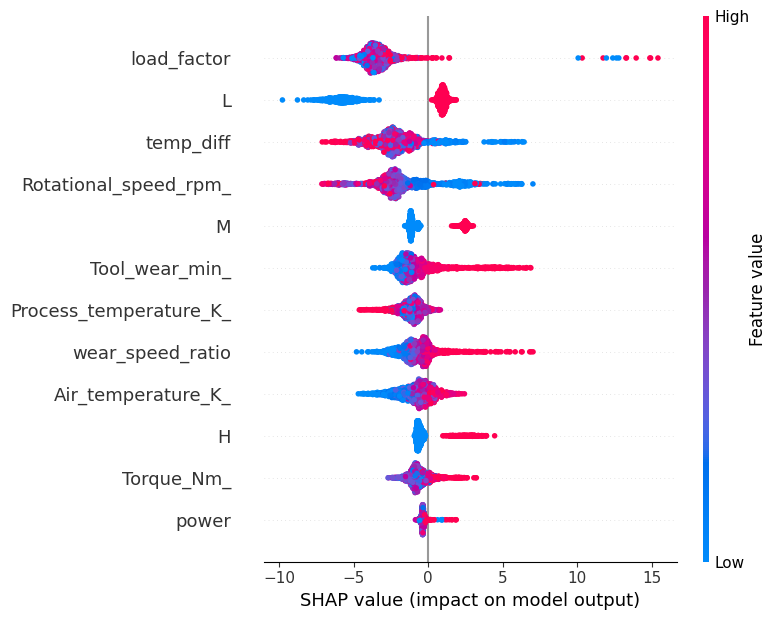

In [30]:
import shap

model = pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

### Confusion Matrix Analysis

The confusion matrix shows the distribution of correct and incorrect predictions:

- True Negatives (Correct non-failure predictions): **1921**
- True Positives (Correct failure predictions): **56**
- False Positives (False alarms): **11**
- False Negatives (Missed failures): **12**

The model maintains a balanced error distribution, ensuring that both false alarms and missed failures are minimized. This balance is critical in predictive maintenance scenarios.

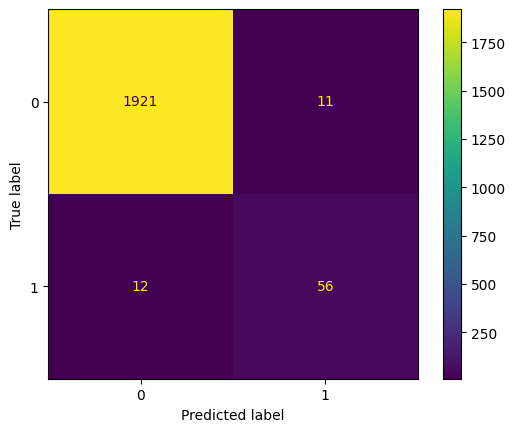

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, Y_test)

### Error Analysis

To better understand model limitations, misclassified instances were analyzed.

The model produced a small number of errors, including both false positives and false negatives. False negatives (missed failures) are particularly critical in predictive maintenance, as they may lead to unexpected machine breakdowns.

This analysis helps identify areas where the model can be further improved and ensures awareness of real-world risks associated with incorrect predictions.

In [32]:

import pandas as pd

results_df = X_test.copy()
results_df['Actual'] = Y_test.values
results_df['Predicted'] = y_pred

# Misclassified cases
errors = results_df[results_df['Actual'] != results_df['Predicted']]

print("Total Errors:", len(errors))
errors.head()

Total Errors: 23


,Air_temperature_K_,Process_temperature_K_,Rotational_speed_rpm_,Torque_Nm_,Tool_wear_min_,H,L,M,temp_diff,load_factor,wear_speed_ratio,power,Actual,Predicted
9174,297.8,308.9,1871,25.6,200,False,True,False,11.1,47897.6,0.106838,798.293333,1,0
2671,299.7,309.3,1399,41.9,221,False,False,True,9.6,58618.1,0.157857,976.968333,1,0
2864,300.6,309.4,1380,47.6,246,True,False,False,8.8,65688.0,0.178132,1094.800000,1,0
5307,304.0,313.3,1530,34.8,211,False,True,False,9.3,53244.0,0.137818,887.400000,0,1
3695,302.2,311.3,1530,37.3,207,False,True,False,9.1,57069.0,0.135206,951.150000,1,0


### Feature Interpretation

The model’s behavior was further analyzed using SHAP values to understand feature importance.

Key observations include:

- **Load Factor**: Higher load increases stress on the machine, making failure more likely.
- **Temperature Difference**: Large differences between process and air temperature indicate abnormal operating conditions.
- **Rotational Speed and Torque**: These directly affect mechanical stress and wear.
- **Tool Wear**: Increased wear is naturally associated with higher failure probability.

These insights align with real-world machine behavior, confirming that the model is learning meaningful and interpretable patterns.

## Model Performance

- Precision: 83.58%
- Recall: 82.35%
- F1 Score: 82.96%

The model demonstrates strong and well-balanced performance, with high recall ensuring most failure cases are correctly identified, while maintaining good precision to limit false alarms.

---

## Threshold Tuning

Threshold tuning was explored to understand the trade-off between precision and recall.

Lowering the decision threshold increases recall by capturing more failure cases, while increasing the threshold improves precision by reducing false positives.

The default threshold (0.5) was retained as it provides a balanced trade-off between precision and recall, aligning well with the project objective of reliable and practical failure prediction.

## Deployment Demonstration

A sample prediction is performed using the deployed model pipeline. 
This demonstrates how raw input data is processed and passed through 
the trained model to generate predictions.

In [33]:
from predict import predict_failure
sample = {
    "Air temperature [K]": 300,
    "Process temperature [K]": 310,
    "Rotational speed [rpm]": 1500,
    "Torque [Nm]": 40,
    "Tool wear [min]": 120,
    "Type": "L"
}

result = predict_failure(sample)

print("Prediction:", result)

Prediction: {'prediction': 0, 'probability': 0.13, 'health_score': 99.87, 'risk': 'Low', 'recommendation': 'Machine operating normally'}


## Conclusion

This project presents a comprehensive predictive maintenance solution designed to identify potential machine failures using sensor-based operational data. The objective was to move from reactive maintenance strategies toward a data-driven, proactive approach that minimizes downtime and operational risk.

The workflow began with thorough data preprocessing, including cleaning, feature transformation, and handling class imbalance using SMOTE. Feature engineering played a key role in improving model performance by capturing meaningful relationships such as thermal imbalance and mechanical load conditions.

Multiple models and optimization strategies were systematically evaluated, including XGBoost, baseline LightGBM, manual hyperparameter tuning, RandomizedSearchCV, probability calibration, and threshold tuning. This iterative approach ensured that model selection was driven by empirical performance rather than assumptions.

The final model — a LightGBM classifier optimized using RandomizedSearchCV — achieved the best overall performance with:

- **Precision:** 83.58%  
- **Recall:** 82.35%  
- **F1 Score:** 82.96%  

This reflects a well-balanced model capable of effectively identifying failure events while minimizing false alarms. In predictive maintenance, false negatives are particularly critical; however, threshold tuning experiments demonstrated that further improvements in recall resulted in a disproportionate increase in false positives. Therefore, the default decision threshold was retained to preserve an optimal balance between safety and operational efficiency.

Model robustness was validated using advanced evaluation techniques, including stratified cross-validation and ROC-AUC analysis (~0.97), confirming strong class separability and consistent performance across multiple data splits. Additionally, confusion matrix analysis provided insight into error distribution, demonstrating that the model maintains low false negatives while controlling false positives within acceptable limits.

To enhance interpretability, SHAP (SHapley Additive exPlanations) analysis was applied, revealing that features related to load conditions and temperature differences significantly influence failure predictions. These insights align with real-world machine behavior, increasing confidence in the model’s decisions.

From a deployment perspective, the solution was designed with production readiness in mind. The preprocessing and prediction logic were encapsulated into a reusable pipeline, ensuring consistency between training and inference. Furthermore, a Streamlit-based application was developed to provide an interactive interface for real-time predictions, making the system accessible to end users without requiring technical expertise.

Overall, this project demonstrates a complete end-to-end machine learning lifecycle, encompassing data preparation, feature engineering, model development, hyperparameter optimization, interpretability, and deployment. The final solution is both scalable and practical, offering a reliable foundation for real-world predictive maintenance systems aimed at improving operational efficiency and reducing unexpected failures.

In [34]:
from joblib import dump
model = pipeline
dump(model, "full_system.pkl")

['full_system.pkl']

## Model Import

The trained machine learning pipeline is imported using `joblib` and loaded into the application at runtime.  
This ensures that the same preprocessing steps and trained model are used consistently during prediction.